<a href="https://colab.research.google.com/github/JoePhillippe/CSC-114/blob/main/Access_AI_Frameworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install keras keras-hub --upgrade -q

Training samples: (16512, 8)
Test samples:     (4128, 8)
Raw target range: $14,999  to  $500,001

Normalized target range: -1.66  to  2.54


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3666 - mae: 0.4402 - val_loss: 0.3043 - val_mae: 0.3801
Epoch 2/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2782 - mae: 0.3751 - val_loss: 0.2806 - val_mae: 0.3629
Epoch 3/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2608 - mae: 0.3621 - val_loss: 0.2738 - val_mae: 0.3773
Epoch 4/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2487 - mae: 0.3530 - val_loss: 0.2652 - val_mae: 0.3523
Epoch 5/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2407 - mae: 0.3451 - val_loss: 0.2561 - val_mae: 0.3459
Epoch 6/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2344 - mae: 0.3388 - val_loss: 0.2588 - val_mae: 0.3410
Epoch 7/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2289 - mae: 0.3338 - val_loss: 0.2457 - val_mae: 0.3318
Epoch 8/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2253 - mae: 0.3304 - val_loss: 0.2414 - val_mae: 0.3341
Epoch 9/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - lo

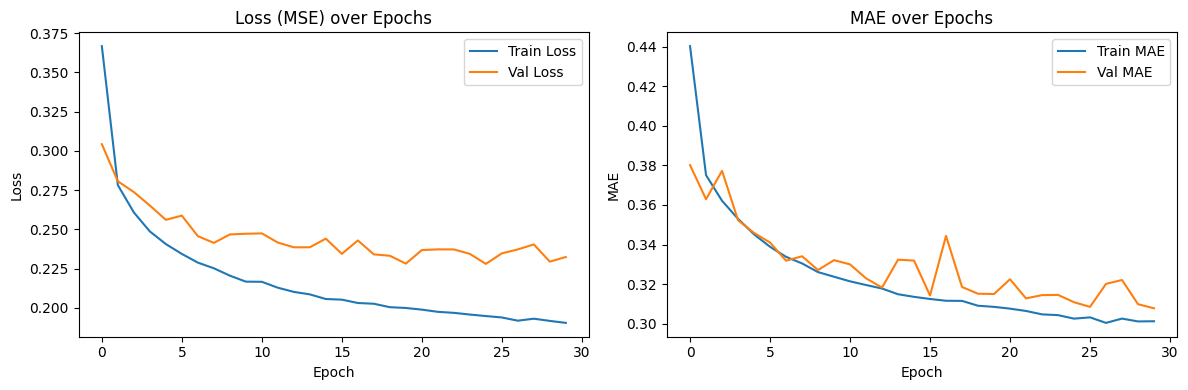

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

--- Sample Predictions vs Actual ---
Predicted: $   217,892   Actual: $   397,900
Predicted: $   219,504   Actual: $   227,900
Predicted: $   167,536   Actual: $   172,100
Predicted: $   221,006   Actual: $   186,500
Predicted: $   180,112   Actual: $   148,900


In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# ── 1. LOAD DATA ──────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = keras.datasets.california_housing.load_data()

print("Training samples:", x_train.shape)
print("Test samples:    ", x_test.shape)
print("Raw target range: ${:,.0f}  to  ${:,.0f}".format(y_train.min(), y_train.max()))

# ── 2. NORMALIZE FEATURES (x) ─────────────────────────────────
# Compute mean and std from TRAINING data only
x_mean = x_train.mean(axis=0)
x_std  = x_train.std(axis=0)

x_train_norm = (x_train - x_mean) / x_std
x_test_norm  = (x_test  - x_mean) / x_std   # use SAME train stats

# ── 3. NORMALIZE TARGET (y) ───────────────────────────────────
# Scale house prices to 0-1 range so model trains smoothly
y_mean = y_train.mean()
y_std  = y_train.std()

y_train_norm = (y_train - y_mean) / y_std
y_test_norm  = (y_test  - y_mean) / y_std

print("\nNormalized target range: {:.2f}  to  {:.2f}".format(
      y_train_norm.min(), y_train_norm.max()))

# ── 4. BUILD THE MODEL ────────────────────────────────────────
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(8,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)          # single number output = regression
])

model.compile(
    optimizer='adam',
    loss='mse',                    # Mean Squared Error for regression
    metrics=['mae']                # Mean Absolute Error - easier to read
)

model.summary()

# ── 5. TRAIN ──────────────────────────────────────────────────
history = model.fit(
    x_train_norm, y_train_norm,
    epochs=30,
    batch_size=32,
    validation_split=0.1,          # hold out 10% of train for validation
    verbose=1
)

# ── 6. EVALUATE ───────────────────────────────────────────────
loss, mae = model.evaluate(x_test_norm, y_test_norm, verbose=0)

# Convert MAE back to real dollars
mae_dollars = mae * y_std
print("\n--- Test Results ---")
print("MAE (normalized): {:.4f}".format(mae))
print("MAE in dollars:  ${:,.0f}".format(mae_dollars))
print("That means predictions are off by about ${:,.0f} on average".format(mae_dollars))

# ── 7. PLOT TRAINING HISTORY ──────────────────────────────────
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss (MSE) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'],     label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# ── 8. SAMPLE PREDICTIONS ─────────────────────────────────────
predictions_norm = model.predict(x_test_norm[:5])

# Convert back to dollars
predictions_dollars = (predictions_norm.flatten() * y_std) + y_mean
actual_dollars      = y_test[:5]

print("\n--- Sample Predictions vs Actual ---")
for i in range(5):
    print("Predicted: ${:>10,.0f}   Actual: ${:>10,.0f}".format(
          predictions_dollars[i], actual_dollars[i]))